## Treci projekat - recenzije filmova

In [1]:
import warnings
warnings.filterwarnings("ignore", module=r"matplotlib\..*")

In [2]:
# Učitavanje movie.csv 
import os
import numpy as np
import pandas as pd

relpath = '..\\data\\movie.csv'
abspath = os.path.abspath(relpath)

try:
    df = pd.read_csv(relpath)
except FileNotFoundError:
    df = pd.read_csv(abspath)

print("Dataset učitan:", df.shape)
df.head()

Dataset učitan: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## Ucitavanje podataka

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.describe()


,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["text", "label"]).copy()

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].copy()

unknown = df["label"].isna().sum()
if unknown > 0:
    print(f"Upozorenje: uklonjeno {unknown} redova sa nepoznatom labelom.")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

df_audit = df.copy()
df_audit["text_norm"] = (
    df_audit["text"].astype(str).str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

conflicts = (
    df_audit.groupby("text_norm")["label"].nunique()
    .reset_index(name="n_unique_labels")
)
conflicts = conflicts[conflicts["n_unique_labels"] > 1]

print("Konfliktni duplikati:", len(conflicts))

to_review = df_audit[df_audit["text_norm"].isin(conflicts["text_norm"])]
to_review[["text", "label"]].drop_duplicates().to_csv("label_conflicts_review.csv", index=False)
print("Sačuvano: label_conflicts_review.csv")

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print("Nakon uklanjanja duplikata:", df.shape)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))

X_temp, X_test, y_temp, y_test = train_test_split(
    df["text"], df["label"], test_size=0.15, random_state=42, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("\nSplit sizes:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Konfliktni duplikati: 0
Sačuvano: label_conflicts_review.csv
Nakon uklanjanja duplikata: (39723, 2)
Shape: (39723, 2)

Class distribution:
label
1    0.501171
0    0.498829
Name: ratio, dtype: float64

Split sizes:
Train: 27804
Val:   5960
Test:  5959


In [6]:
#%pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters
VOCAB_SIZE = 20000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

# Keras Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

# Convert text -> sequences
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (27804, 200)
Val padded shape: (5960, 200)
Test padded shape: (5959, 200)


Primer tokenizacije iz train seta:
   label                                                                                                                text_preview                                                                                    seq_preview                                                                                                                               tokens_preview  n_tokens
negative this is the worst film i have ever seen and what disappoints me the most is that this is yash raj film so at first when ...            [12, 7, 2, 246, 20, 11, 26, 124, 107, 3, 49, 12311, 69, 2, 89, 7, 13, 12, 7, 14191]                           [this, is, the, worst, film, i, have, ever, seen, and, what, disappoints, me, the, most, is, that, this, is, yash]       144
positive I wanted to see Sarah Buffy on the big screen, so I first bought tickets and then checked the reviews at IMDb. I worried...     [11, 453, 6, 64, 2472, 7737, 21, 2, 188, 264, 36, 11, 88, 1202, 6296, 

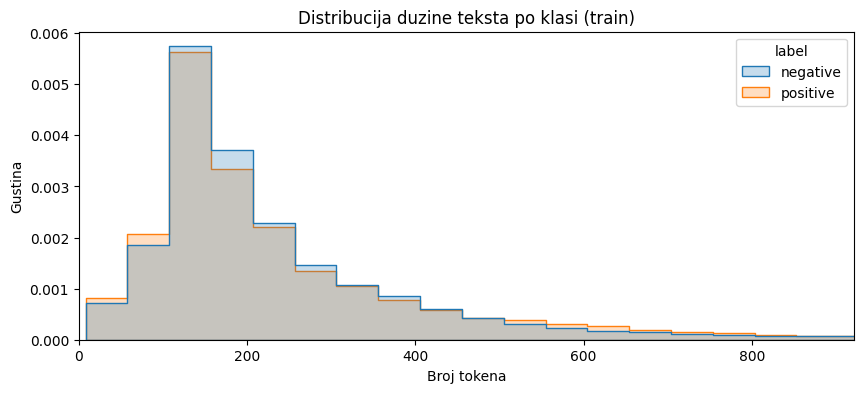


Najcesci tokeni u negative klasi:
token  count    share
  the 179774 0.057440
    a  87408 0.027928
  and  81275 0.025969
   of  75508 0.024126
   to  75183 0.024022
   br  57812 0.018472
   is  54877 0.017534
   in  47892 0.015302
    i  44941 0.014359
 this  44837 0.014326
   it  43347 0.013850
 that  38947 0.012444
  was  28910 0.009237
movie  27264 0.008711
  for  23872 0.007627

Najcesci tokeni u positive klasi:
token  count    share
  the 192822 0.059450
  and  99447 0.030661
    a  92787 0.028608
   of  86150 0.026561
   to  74343 0.022921
   is  63111 0.019458
   in  56427 0.017397
   br  55516 0.017116
   it  43992 0.013563
    i  41291 0.012731
 this  39089 0.012052
 that  37743 0.011637
   as  28963 0.008930
 with  25610 0.007896
  for  25144 0.007752


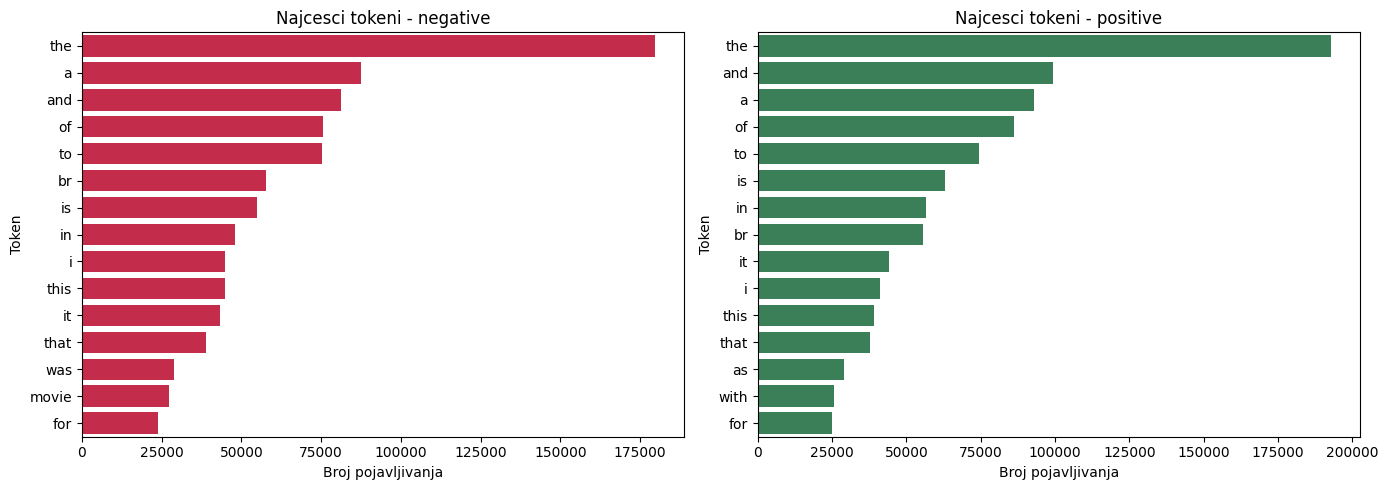


Tokeni karakteristicniji za negative klasu:
token  neg_count  pos_count  freq_diff
 this      44837      39089  -0.002274
movie      27264      21150  -0.002190
  bad       7988       2123  -0.001898
  was      28910      24542  -0.001670
    i      44941      41291  -0.001629
   br      57812      55516  -0.001355
 just      11580       7921  -0.001258
   no       8965       5231  -0.001252
 have      17010      13875  -0.001157
   to      75183      74343  -0.001101
 even       8500       5418  -0.001045
 they      13067      10151  -0.001045
   or      11230       8687  -0.000910
 like      12370       9905  -0.000899
   if      10548       8250  -0.000827

Tokeni karakteristicniji za positive klasu:
token  neg_count  pos_count  freq_diff
  and      81275      99447   0.004693
   of      75508      86150   0.002436
   in      47892      56427   0.002095
  the     179774     192822   0.002010
   is      54877      63111   0.001924
  his      13012      19176   0.001755
   as      22

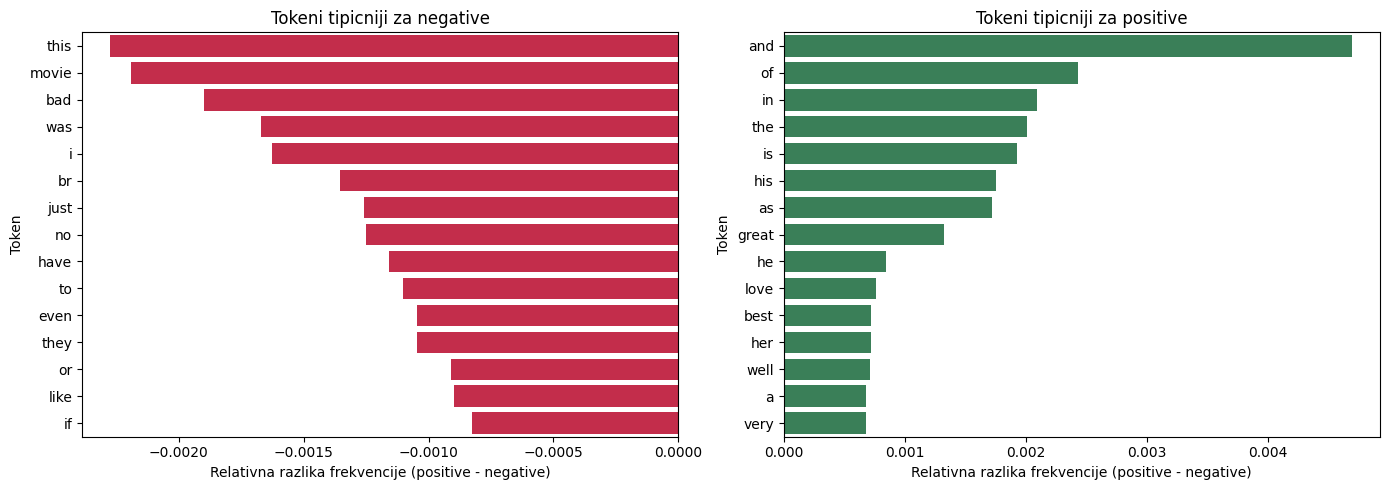

In [7]:
from collections import Counter

# Mapa: token_id -> rec
index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

def decode_tokens(seq, limit=20):
    return [index_to_word.get(tok, OOV_TOKEN if tok == 1 else f"<{tok}>") for tok in seq[:limit]]

def short_text(text, limit=120):
    text = str(text).replace("\n", " ").strip()
    return text[:limit] + ("..." if len(text) > limit else "")

# 1) Primeri kako je tekst tokenizovan
sample_idx = [0, 1, 2, 3, 4]
sample_token_df = pd.DataFrame({
    "label": ["positive" if y_train_np[i] == 1 else "negative" for i in sample_idx],
    "text_preview": [short_text(X_train.iloc[i]) for i in sample_idx],
    "seq_preview": [train_seq[i][:20] for i in sample_idx],
    "tokens_preview": [decode_tokens(train_seq[i], 20) for i in sample_idx],
    "n_tokens": [len(train_seq[i]) for i in sample_idx]
})

print("Primer tokenizacije iz train seta:")
print(sample_token_df.to_string(index=False))

# 2) Analiza duzine teksta
train_lengths = np.array([len(seq) for seq in train_seq])
length_df = pd.DataFrame({
    "label": np.where(y_train_np == 1, "positive", "negative"),
    "n_tokens": train_lengths
})

print("\nStatistika duzine review-a po klasi:")
print(length_df.groupby("label")["n_tokens"].describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(
    data=length_df,
    x="n_tokens",
    hue="label",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.xlim(0, np.percentile(train_lengths, 99))
plt.title("Distribucija duzine teksta po klasi (train)")
plt.xlabel("Broj tokena")
plt.ylabel("Gustina")
plt.show()

# 3) Najcesci tokeni po klasi
neg_counter = Counter()
pos_counter = Counter()

for seq, label in zip(train_seq, y_train_np):
    valid_seq = [tok for tok in seq if 1 < tok < VOCAB_SIZE]  # izbacuje OOV
    if label == 0:
        neg_counter.update(valid_seq)
    else:
        pos_counter.update(valid_seq)

def top_tokens_df(counter, top_n=15):
    total = sum(counter.values())
    rows = []
    for tok_id, cnt in counter.most_common(top_n):
        rows.append({
            "token_id": tok_id,
            "token": index_to_word.get(tok_id, "<UNK>"),
            "count": cnt,
            "share": cnt / total
        })
    return pd.DataFrame(rows)

top_neg = top_tokens_df(neg_counter, top_n=15)
top_pos = top_tokens_df(pos_counter, top_n=15)

print("\nNajcesci tokeni u negative klasi:")
print(top_neg[["token", "count", "share"]].to_string(index=False))

print("\nNajcesci tokeni u positive klasi:")
print(top_pos[["token", "count", "share"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_neg, x="count", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Najcesci tokeni - negative")
axes[0].set_xlabel("Broj pojavljivanja")
axes[0].set_ylabel("Token")

sns.barplot(data=top_pos, x="count", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Najcesci tokeni - positive")
axes[1].set_xlabel("Broj pojavljivanja")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

# 4) Tokeni koji su karakteristicniji za jednu od dve klase
neg_total = sum(neg_counter.values())
pos_total = sum(pos_counter.values())

rows = []
all_tok_ids = set(neg_counter.keys()) | set(pos_counter.keys())

for tok_id in all_tok_ids:
    neg_cnt = neg_counter[tok_id]
    pos_cnt = pos_counter[tok_id]
    total_cnt = neg_cnt + pos_cnt

    if total_cnt < 30:
        continue

    neg_freq = neg_cnt / neg_total
    pos_freq = pos_cnt / pos_total

    rows.append({
        "token_id": tok_id,
        "token": index_to_word.get(tok_id, "<UNK>"),
        "neg_count": neg_cnt,
        "pos_count": pos_cnt,
        "neg_freq": neg_freq,
        "pos_freq": pos_freq,
        "freq_diff": pos_freq - neg_freq,
        "total_count": total_cnt
    })

token_stats_df = pd.DataFrame(rows)

most_negative = token_stats_df.sort_values("freq_diff").head(15).copy()
most_positive = token_stats_df.sort_values("freq_diff", ascending=False).head(15).copy()

print("\nTokeni karakteristicniji za negative klasu:")
print(most_negative[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

print("\nTokeni karakteristicniji za positive klasu:")
print(most_positive[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=most_negative, x="freq_diff", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Tokeni tipicniji za negative")
axes[0].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[0].set_ylabel("Token")

sns.barplot(data=most_positive, x="freq_diff", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Tokeni tipicniji za positive")
axes[1].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers, callbacks, models
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_pad, y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=12,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}
Epoch 1/12


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


435/435 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.7923 - loss: 0.4256 - precision: 0.8017 - recall: 0.7779 - val_accuracy: 0.8772 - val_loss: 0.3011 - val_precision: 0.8780 - val_recall: 0.8768 - learning_rate: 5.0000e-04
Epoch 2/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8959 - loss: 0.2575 - precision: 0.8985 - recall: 0.8920
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
435/435 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.9130 - loss: 0.2251 - precision: 0.9146 - recall: 0.9116 - val_accuracy: 0.8659 - val_loss: 0.3552 - val_precision: 0.8601 - val_recall: 0.8748 - learning_rate: 5.0000e-04
Epoch 3/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9456 - loss: 0.1554 - precision: 0.9481 - recall: 0.9425
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
435/435 ━━━━━━━━━━━━━━━━━━━━ 37s 86ms/step - accuracy: 0.9554 - loss: 0.1285 - precision: 0.9573 - recall: 0.9536 - val_accuracy: 0.8644 - val

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_pad, y_test_np, verbose=0)
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1:        {f1_score(y_test_np, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test_np, y_pred, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred))

Test Accuracy:  0.8681
Test Precision: 0.8621
Test Recall:    0.8771
Test F1:        0.8695

Classification report:
              precision    recall  f1-score   support

           0     0.8744    0.8591    0.8666      2973
           1     0.8621    0.8771    0.8695      2986

    accuracy                         0.8681      5959
   macro avg     0.8682    0.8681    0.8681      5959
weighted avg     0.8682    0.8681    0.8681      5959

Confusion matrix:
[[2554  419]
 [ 367 2619]]


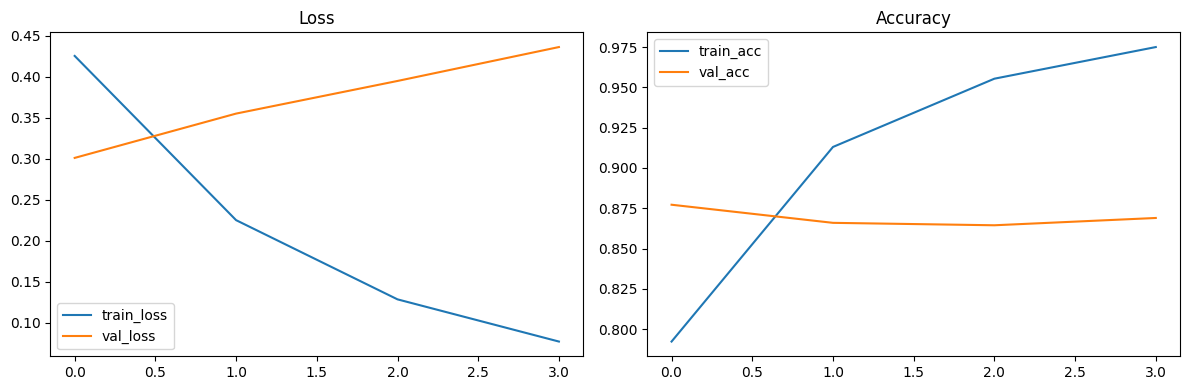

In [10]:
import matplotlib.pyplot as plt

# history from model.fit(...)
hist = history.history

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight)

def compute_metrics_hf(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def tune_threshold_from_scores(y_true, scores):
    scores = np.asarray(scores).ravel()
    thresholds = np.unique(np.quantile(scores, np.linspace(0.05, 0.95, 91)))

    best_thr = float(thresholds[0])
    best_f1 = -1.0

    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_thr = float(thr)

    return best_thr, best_f1

def get_continuous_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(X)).ravel()
    return None

all_results = []
trained_models = {}

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC

sklearn_setups = {
    "tfidf_mnb": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=40000, min_df=2, sublinear_tf=True)),
        ("clf", MultinomialNB(alpha=0.5)),
    ]),
    "tfidf_cnb": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=40000, min_df=2, sublinear_tf=True)),
        ("clf", ComplementNB(alpha=0.5)),
    ]),
    "tfidf_logreg_word": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(C=2.0, max_iter=2000, solver="liblinear", class_weight="balanced")),
    ]),
    "tfidf_logreg_char": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=60000, min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(C=4.0, max_iter=2000, solver="liblinear", class_weight="balanced")),
    ]),
    "tfidf_linearsvc_word": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", LinearSVC(C=1.0, class_weight="balanced")),
    ]),
    "tfidf_sgd_logloss": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=2000, random_state=42, class_weight="balanced")),
    ]),
    "tfidf_passive_aggressive": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", PassiveAggressiveClassifier(C=0.5, max_iter=2000, random_state=42, class_weight="balanced")),
    ]),
}

for name, pipe in sklearn_setups.items():
    print(f"\n=== Scikit-Learn: {name} ===")
    pipe.fit(X_train, y_train_np)

    val_scores = get_continuous_scores(pipe, X_val)
    if val_scores is not None:
        best_thr, val_best_f1 = tune_threshold_from_scores(y_val_np, val_scores)
        val_pred = (val_scores >= best_thr).astype(int)
        test_scores = get_continuous_scores(pipe, X_test)
        test_pred = (test_scores >= best_thr).astype(int)
    else:
        best_thr = None
        val_pred = pipe.predict(X_val)
        test_pred = pipe.predict(X_test)
        val_best_f1 = f1_score(y_val_np, val_pred, zero_division=0)

    val_metrics = compute_metrics_hf(y_val_np, val_pred)
    test_metrics = compute_metrics_hf(y_test_np, test_pred)

    row = {
        "family": "sklearn",
        "model": name,
        "threshold": best_thr,
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }
    all_results.append(row)

    trained_models[name] = {
        "family": "sklearn",
        "model": pipe,
        "threshold": best_thr,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    print("Val F1:", round(val_metrics["f1"], 4))
    print("Test F1:", round(test_metrics["f1"], 4))


=== Scikit-Learn: tfidf_mnb ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Val F1: 0.8887
Test F1: 0.8817

=== Scikit-Learn: tfidf_cnb ===
Val F1: 0.8887
Test F1: 0.8817

=== Scikit-Learn: tfidf_logreg_word ===
Val F1: 0.9112
Test F1: 0.9082

=== Scikit-Learn: tfidf_logreg_char ===
Val F1: 0.9027
Test F1: 0.8988

=== Scikit-Learn: tfidf_linearsvc_word ===
Val F1: 0.9119
Test F1: 0.9116

=== Scikit-Learn: tfidf_sgd_logloss ===
Val F1: 0.9129
Test F1: 0.9107

=== Scikit-Learn: tfidf_passive_aggressive ===
Val F1: 0.9013
Test F1: 0.901


In [14]:
from tensorflow.keras import layers, models, callbacks

def compile_binary_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_avg_pool(vocab_size, max_len, emb_dim=128, dense_units=64, drop=0.3, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_cnn(vocab_size, max_len, emb_dim=128, filters=128, kernel_size=5, drop=0.5, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_lstm(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.LSTM(units),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_gru(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.GRU(units),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_bilstm(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_bigru(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.Bidirectional(layers.GRU(units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

tf_setups = [
    {"name": "tf_avgpool_128", "builder": build_avg_pool, "params": {"emb_dim": 128, "dense_units": 64, "drop": 0.3, "lr": 1e-3}, "epochs": 10, "batch_size": 128},

    {"name": "tf_cnn_128", "builder": build_cnn, "params": {"emb_dim": 128, "filters": 128, "kernel_size": 5, "drop": 0.5, "lr": 1e-3}, "epochs": 10, "batch_size": 128},
    {"name": "tf_cnn_32", "builder": build_cnn, "params": {"emb_dim": 128, "filters": 32, "kernel_size": 5, "drop": 0.5, "lr": 1e-3}, "epochs": 10, "batch_size": 128},

    {"name": "tf_cnn_64_small", "builder": build_cnn, "params": {"emb_dim": 64, "filters": 64, "kernel_size": 3, "drop": 0.6, "lr": 5e-4}, "epochs": 10, "batch_size": 128},
    {"name": "tf_cnn_32_small", "builder": build_cnn, "params": {"emb_dim": 64, "filters": 32, "kernel_size": 3, "drop": 0.6, "lr": 5e-4}, "epochs": 10, "batch_size": 128},
    {"name": "tf_cnn_16_small", "builder": build_cnn, "params": {"emb_dim": 64, "filters": 16, "kernel_size": 3, "drop": 0.7, "lr": 3e-4}, "epochs": 10, "batch_size": 128},
    {"name": "tf_cnn_32_tinyemb", "builder": build_cnn, "params": {"emb_dim": 32, "filters": 32, "kernel_size": 3, "drop": 0.6, "lr": 5e-4}, "epochs": 10, "batch_size": 128},

    {"name": "tf_lstm_64", "builder": build_lstm, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_lstm_128", "builder": build_lstm, "params": {"emb_dim": 128, "units": 128, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_gru_64", "builder": build_gru, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_gru_128", "builder": build_gru, "params": {"emb_dim": 128, "units": 128, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_bilstm_64", "builder": build_bilstm, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_bigru_64", "builder": build_bigru, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
]

for cfg in tf_setups:
    tf.keras.backend.clear_session()
    name = cfg["name"]
    print(f"\n=== TensorFlow: {name} ===")

    model = cfg["builder"](VOCAB_SIZE, MAX_LEN, **cfg["params"])

    es = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=0)

    history = model.fit(
        X_train_pad, y_train_np,
        validation_data=(X_val_pad, y_val_np),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        class_weight=class_weight,
        callbacks=[es, rlr],
        verbose=0
    )

    val_scores = model.predict(X_val_pad, verbose=0).ravel()
    best_thr, _ = tune_threshold_from_scores(y_val_np, val_scores)
    val_pred = (val_scores >= best_thr).astype(int)

    test_scores = model.predict(X_test_pad, verbose=0).ravel()
    test_pred = (test_scores >= best_thr).astype(int)

    val_metrics = compute_metrics_hf(y_val_np, val_pred)
    test_metrics = compute_metrics_hf(y_test_np, test_pred)

    row = {
        "family": "tensorflow",
        "model": name,
        "threshold": best_thr,
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }
    all_results.append(row)

    trained_models[name] = {
        "family": "tensorflow",
        "model": model,
        "threshold": best_thr,
        "history": history.history,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    print("Val F1:", round(val_metrics["f1"], 4))
    print("Test F1:", round(test_metrics["f1"], 4))



=== TensorFlow: tf_avgpool_128 ===
Val F1: 0.8822
Test F1: 0.8745

=== TensorFlow: tf_cnn_128 ===
Val F1: 0.8848
Test F1: 0.8802

=== TensorFlow: tf_cnn_32 ===
Val F1: 0.8777
Test F1: 0.8716

=== TensorFlow: tf_cnn_64_small ===
Val F1: 0.8791
Test F1: 0.8704

=== TensorFlow: tf_cnn_32_small ===
Val F1: 0.869
Test F1: 0.8659

=== TensorFlow: tf_cnn_16_small ===
Val F1: 0.8642
Test F1: 0.8542

=== TensorFlow: tf_cnn_32_tinyemb ===
Val F1: 0.8715
Test F1: 0.8605

=== TensorFlow: tf_lstm_64 ===
Val F1: 0.8692
Test F1: 0.8659

=== TensorFlow: tf_lstm_128 ===
Val F1: 0.8669
Test F1: 0.8586

=== TensorFlow: tf_gru_64 ===
Val F1: 0.8658
Test F1: 0.8643

=== TensorFlow: tf_gru_128 ===
Val F1: 0.8725
Test F1: 0.8661

=== TensorFlow: tf_bilstm_64 ===
Val F1: 0.8727
Test F1: 0.8707

=== TensorFlow: tf_bigru_64 ===
Val F1: 0.8718
Test F1: 0.866


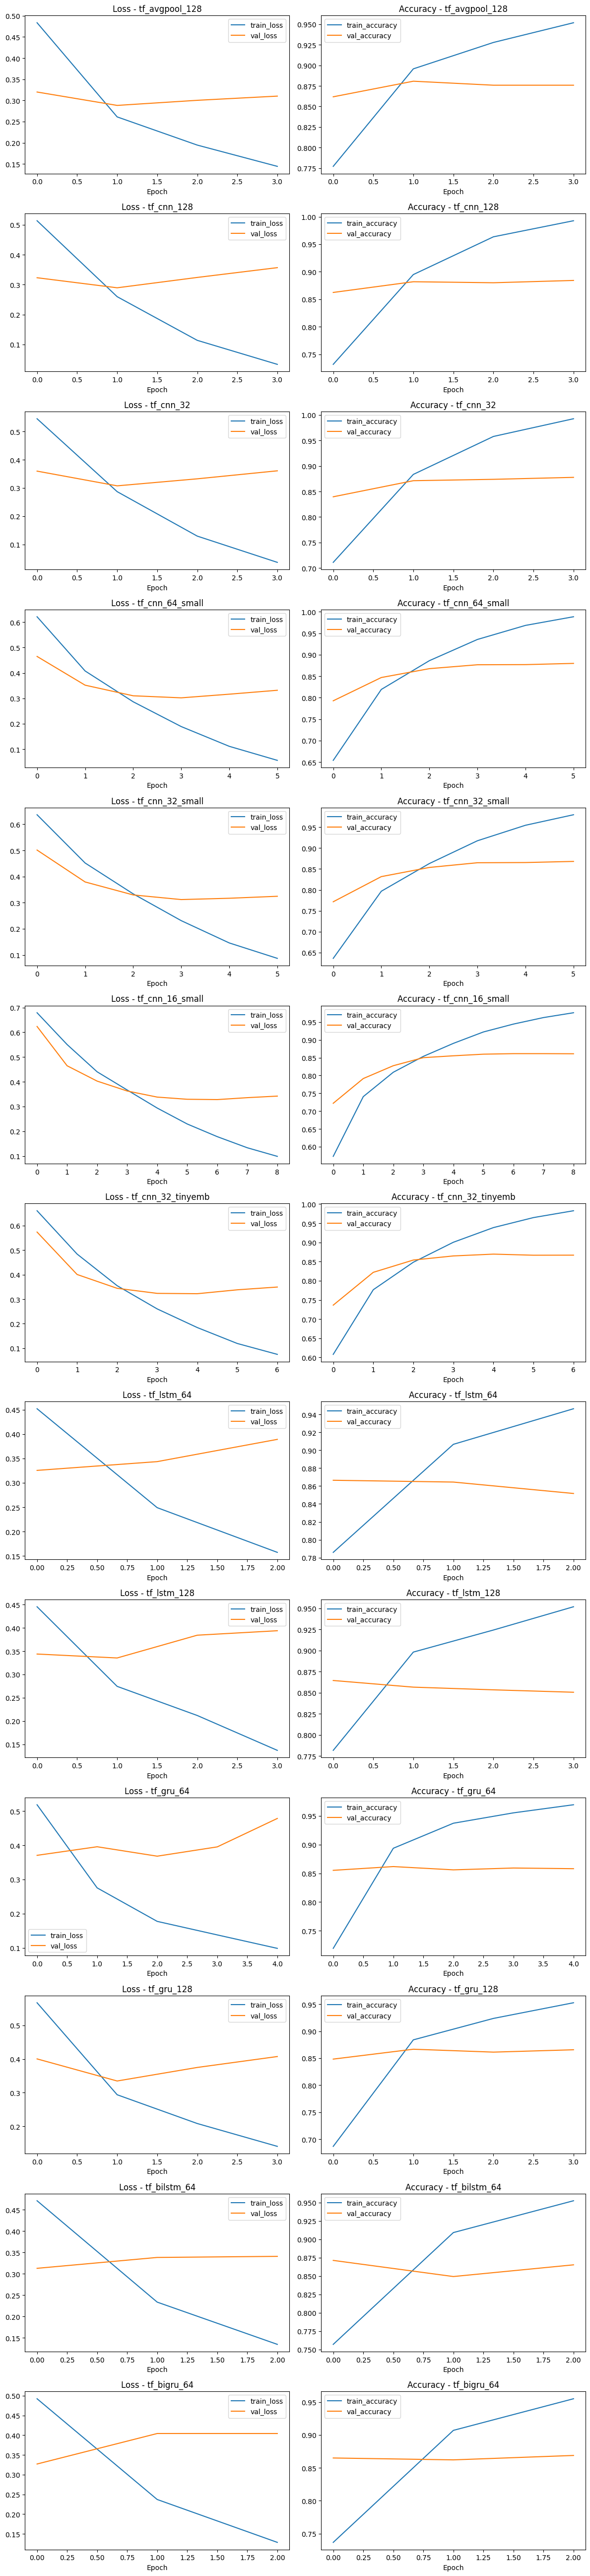

In [15]:
import matplotlib.pyplot as plt

tf_models_with_history = {
    name: entry for name, entry in trained_models.items()
    if entry["family"] == "tensorflow" and "history" in entry
}

n = len(tf_models_with_history)
if n > 0:
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    for i, (name, entry) in enumerate(tf_models_with_history.items()):
        hist = entry["history"]

        axes[i][0].plot(hist.get("loss", []), label="train_loss")
        axes[i][0].plot(hist.get("val_loss", []), label="val_loss")
        axes[i][0].set_title(f"Loss - {name}")
        axes[i][0].set_xlabel("Epoch")
        axes[i][0].legend()

        axes[i][1].plot(hist.get("accuracy", []), label="train_accuracy")
        axes[i][1].plot(hist.get("val_accuracy", []), label="val_accuracy")
        axes[i][1].set_title(f"Accuracy - {name}")
        axes[i][1].set_xlabel("Epoch")
        axes[i][1].legend()

    plt.tight_layout()
    plt.show()

Overfitting analiza (acc_gap > 0.05, loss_gap > 0.2 = potencijalni overfit):


,model,train_acc_last,val_acc_last,acc_gap,train_loss_last,val_loss_last,loss_gap,val_f1,test_f1,f1_gap
6,tf_cnn_32_tinyemb,0.9826,0.8668,0.1158,0.0752,0.3495,0.2743,0.8715,0.8605,0.0110
5,tf_cnn_16_small,0.9763,0.8611,0.1152,0.0985,0.3421,0.2436,0.8642,0.8542,0.0099
2,tf_cnn_32,0.9926,0.8777,0.1149,0.0364,0.3607,0.3243,0.8777,0.8716,0.0061
4,tf_cnn_32_small,0.9799,0.8681,0.1118,0.0870,0.3246,0.2376,0.8690,0.8659,0.0030
9,tf_gru_64,0.9693,0.8581,0.1112,0.0983,0.4785,0.3802,0.8658,0.8643,0.0015
3,tf_cnn_64_small,0.9885,0.8799,0.1086,0.0558,0.3318,0.2760,0.8791,0.8704,0.0086
1,tf_cnn_128,0.9927,0.8842,0.1085,0.0336,0.3569,0.3234,0.8848,0.8802,0.0046
8,tf_lstm_128,0.9520,0.8507,0.1013,0.1368,0.3939,0.2571,0.8669,0.8586,0.0082
7,tf_lstm_64,0.9463,0.8517,0.0947,0.1574,0.3891,0.2317,0.8692,0.8659,0.0033
11,tf_bilstm_64,0.9526,0.8653,0.0873,0.1348,0.3408,0.2060,0.8727,0.8707,0.0020


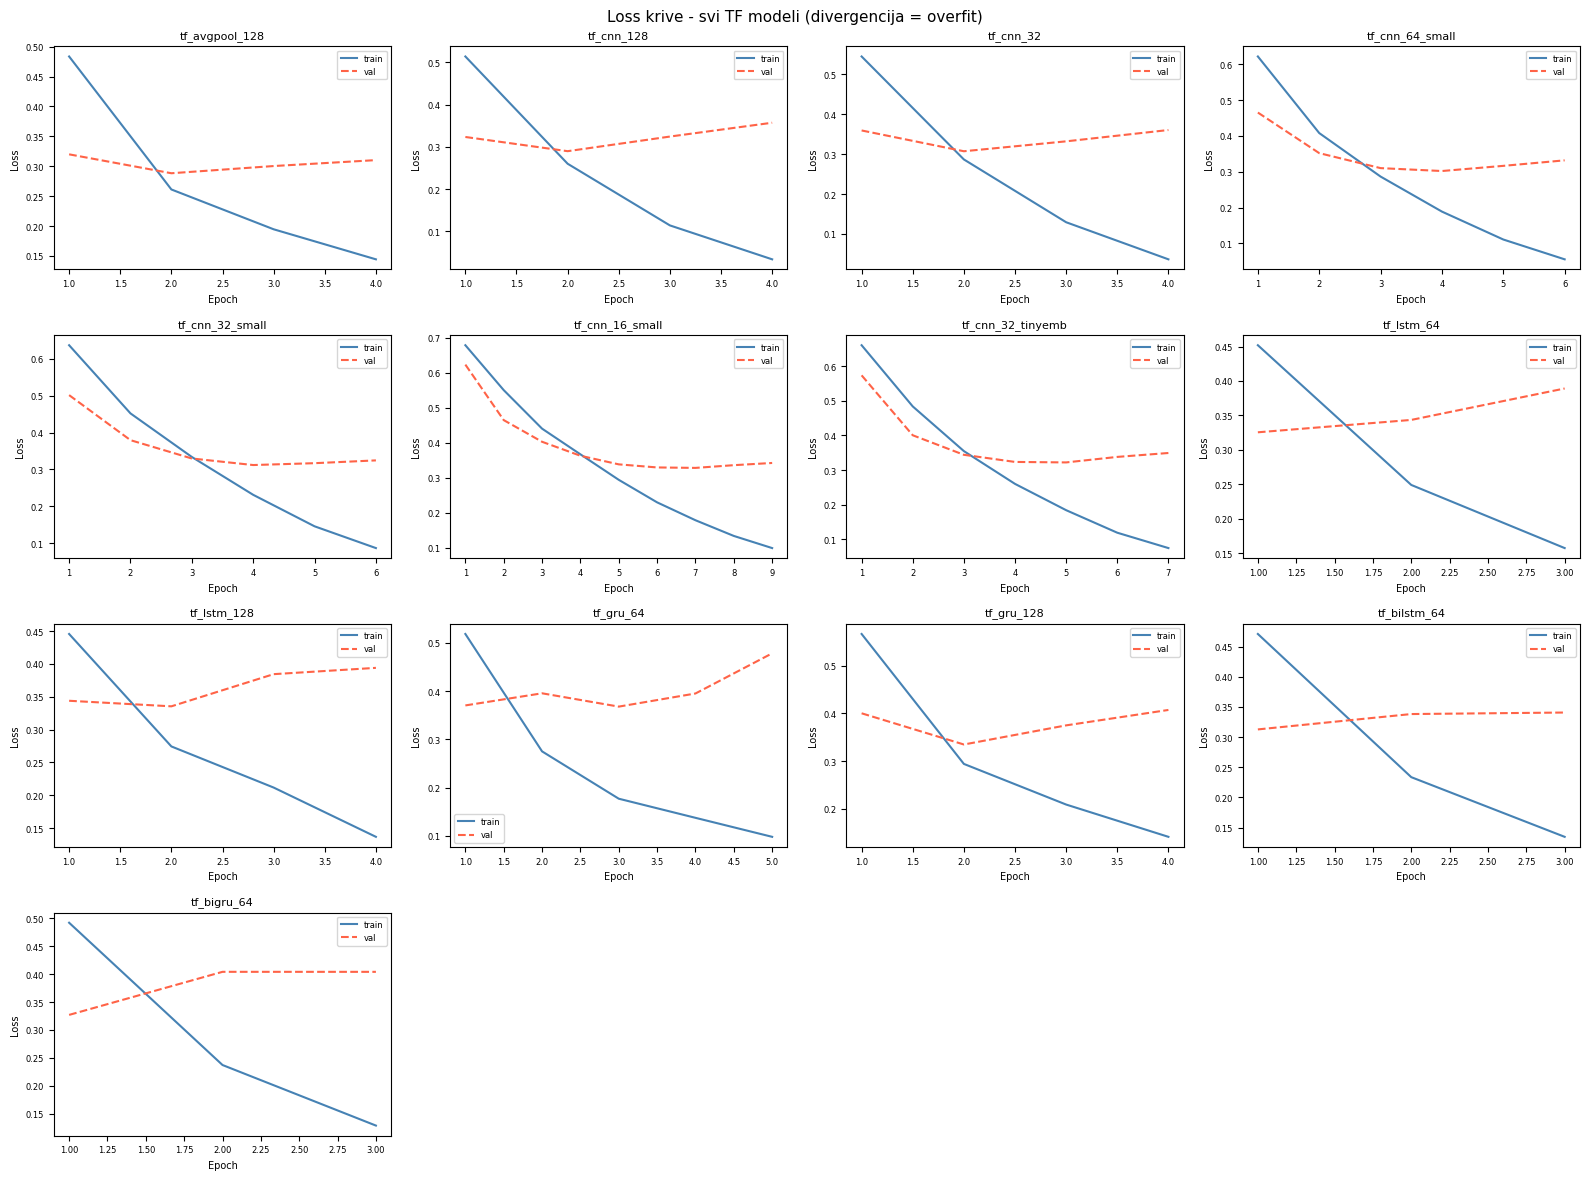

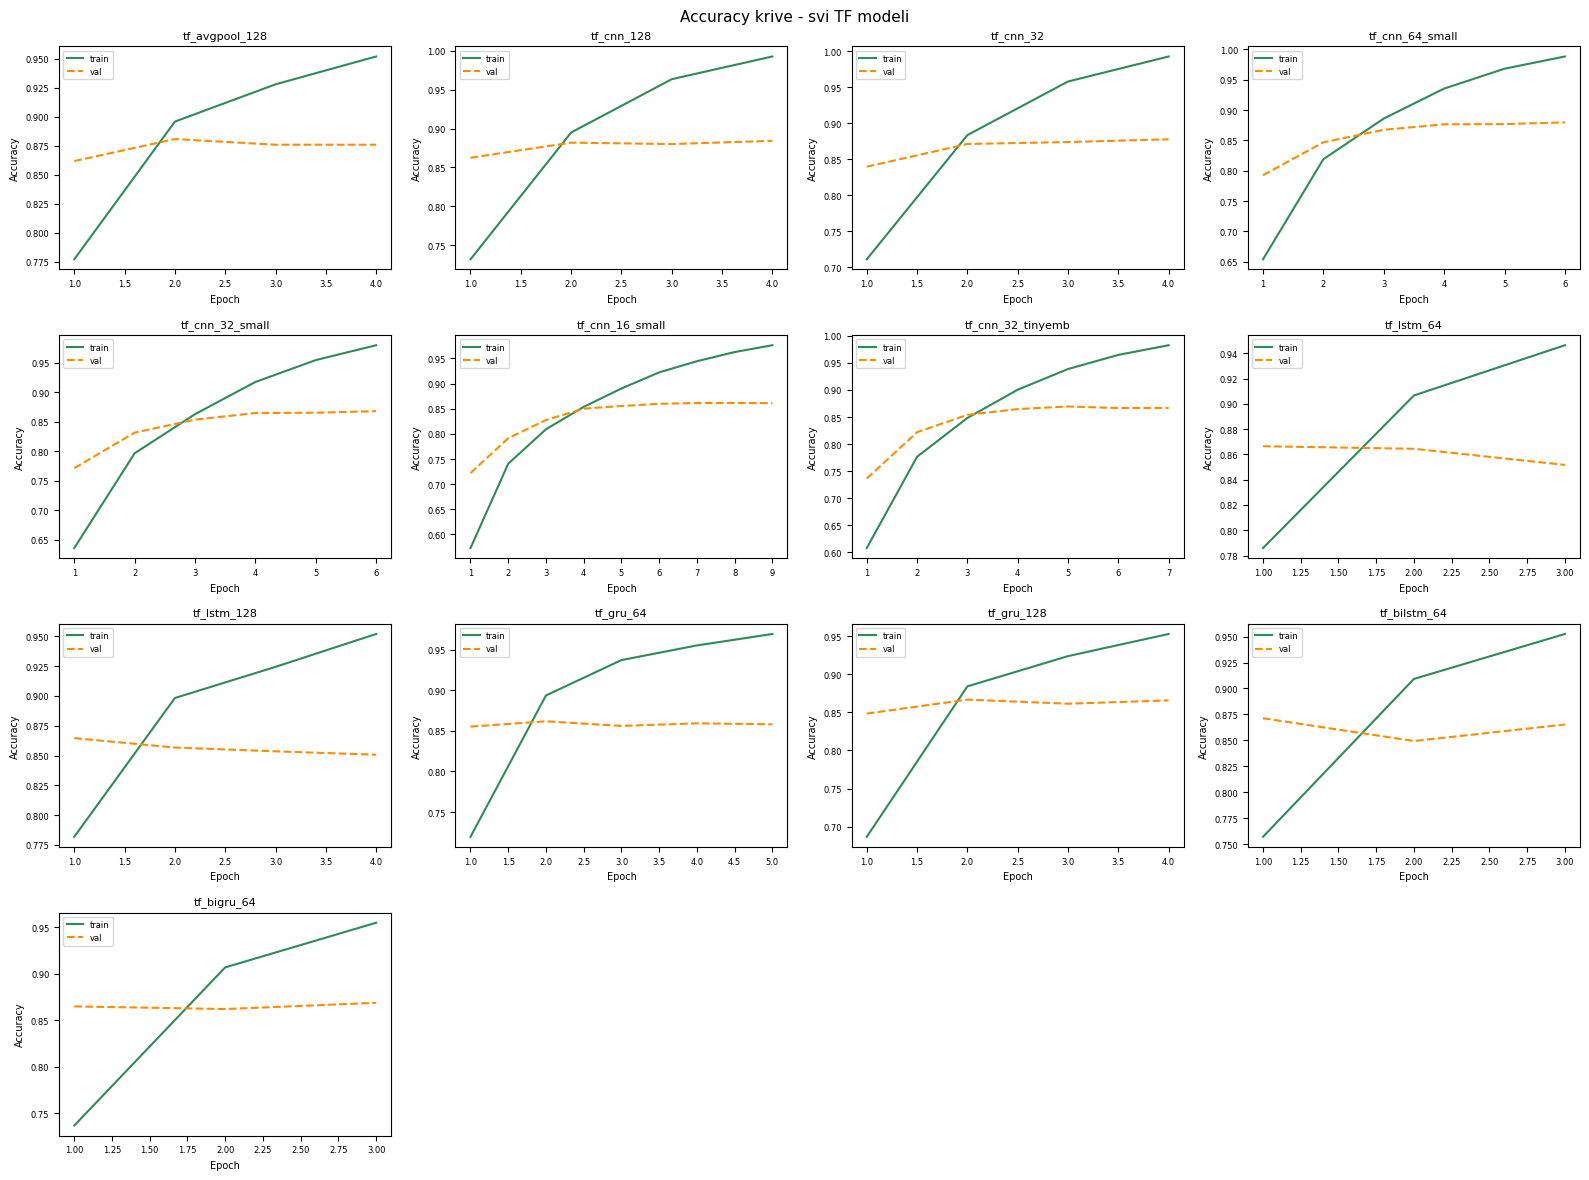

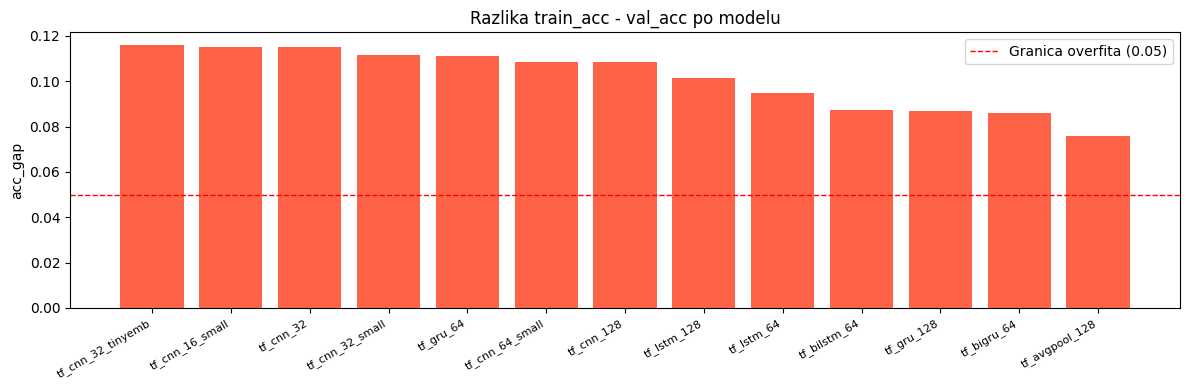

In [16]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gap_rows = []

for cfg in tf_setups:
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        continue

    hist = entry["history"]
    
    train_acc_last = hist["accuracy"][-1]
    val_acc_last   = hist["val_accuracy"][-1]
    train_loss_last = hist["loss"][-1]
    val_loss_last   = hist["val_loss"][-1]
    
    # Val F1 i Test F1 iz all_results
    row_res = next((r for r in all_results if r["model"] == name), None)
    val_f1  = row_res["val_f1"]  if row_res else None
    test_f1 = row_res["test_f1"] if row_res else None
    
    gap_rows.append({
        "model":           name,
        "train_acc_last":  round(train_acc_last, 4),
        "val_acc_last":    round(val_acc_last, 4),
        "acc_gap":         round(train_acc_last - val_acc_last, 4),   
        "train_loss_last": round(train_loss_last, 4),
        "val_loss_last":   round(val_loss_last, 4),
        "loss_gap":        round(val_loss_last - train_loss_last, 4),
        "val_f1":          round(val_f1, 4)  if val_f1  else None,
        "test_f1":         round(test_f1, 4) if test_f1 else None,
        "f1_gap":          round(val_f1 - test_f1, 4) if (val_f1 and test_f1) else None,
    })

gap_df = pd.DataFrame(gap_rows).sort_values("acc_gap", ascending=False)
print("Overfitting analiza (acc_gap > 0.05, loss_gap > 0.2 = potencijalni overfit):")
display(gap_df)

# 2) Subplot: loss krive za sve TF modele (lako videti divergenciju)
n = len(tf_setups)
cols = 4
rows_plot = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_plot, cols, figsize=(cols * 4, rows_plot * 3))
axes = axes.flatten()

for i, cfg in enumerate(tf_setups):
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        axes[i].set_visible(False)
        continue
    
    hist = entry["history"]
    epochs = range(1, len(hist["loss"]) + 1)
    
    axes[i].plot(epochs, hist["loss"],     label="train", color="steelblue")
    axes[i].plot(epochs, hist["val_loss"], label="val",   color="tomato", linestyle="--")
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("Epoch", fontsize=7)
    axes[i].set_ylabel("Loss",  fontsize=7)
    axes[i].legend(fontsize=6)
    axes[i].tick_params(labelsize=6)

# Sakrij prazne subplot-ove
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Loss krive - svi TF modeli (divergencija = overfit)", fontsize=11)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(rows_plot, cols, figsize=(cols * 4, rows_plot * 3))
axes2 = axes2.flatten()

for i, cfg in enumerate(tf_setups):
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        axes2[i].set_visible(False)
        continue
    
    hist = entry["history"]
    epochs = range(1, len(hist["accuracy"]) + 1)
    
    axes2[i].plot(epochs, hist["accuracy"],     label="train", color="seagreen")
    axes2[i].plot(epochs, hist["val_accuracy"], label="val",   color="darkorange", linestyle="--")
    axes2[i].set_title(name, fontsize=8)
    axes2[i].set_xlabel("Epoch", fontsize=7)
    axes2[i].set_ylabel("Accuracy", fontsize=7)
    axes2[i].legend(fontsize=6)
    axes2[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

plt.suptitle("Accuracy krive - svi TF modeli", fontsize=11)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
colors = ["tomato" if g > 0.05 else "steelblue" for g in gap_df["acc_gap"]]
plt.bar(gap_df["model"], gap_df["acc_gap"], color=colors)
plt.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Granica overfita (0.05)")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.title("Razlika train_acc - val_acc po modelu")
plt.ylabel("acc_gap")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

NEG_WORDS = {"not", "no", "never", "n't"}
CONTRAST = {"but", "however", "although", "though", "yet", "nevertheless"}

def mark_negation_and_contrast(text):
    text = str(text).lower()
    tokens = re.findall(r"\w+|[^\w\s]", text)
    out, neg = [], False
    for t in tokens:
        if t in {".", "!", "?", ",", ";", ":"}:
            neg = False
            out.append(t)
            continue
        if t in NEG_WORDS:
            neg = True
            out.append(t)
            continue
        if t in CONTRAST:
            out.append("__CONTRAST__")
            out.append(t)
            continue
        out.append(f"{t}_NEG" if neg and re.match(r"\w+", t) else t)
    return " ".join(out)

pipe_neg = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=mark_negation_and_contrast,
        ngram_range=(1, 2),
        max_features=60000,
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(C=2.0, max_iter=3000, class_weight="balanced"))
])

name = "tfidf_logreg_negcontrast"
pipe_neg.fit(X_train, y_train_np)

val_scores = get_continuous_scores(pipe_neg, X_val)
best_thr, _ = tune_threshold_from_scores(y_val_np, val_scores)
val_pred = (val_scores >= best_thr).astype(int)

test_scores = get_continuous_scores(pipe_neg, X_test)
test_pred = (test_scores >= best_thr).astype(int)

val_metrics = compute_metrics_hf(y_val_np, val_pred)
test_metrics = compute_metrics_hf(y_test_np, test_pred)

all_results.append({
    "family": "sklearn",
    "model": name,
    "threshold": float(best_thr),
    "val_f1": val_metrics["f1"],
    "test_f1": test_metrics["f1"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
})

trained_models[name] = {
    "family": "sklearn",
    "model": pipe_neg,
    "threshold": float(best_thr),
    "val_pred": val_pred,
    "test_pred": test_pred,
}

print(f"{name} | Val F1={val_metrics['f1']:.4f} | Test F1={test_metrics['f1']:.4f}")


tfidf_logreg_negcontrast | Val F1=0.9142 | Test F1=0.9075


In [18]:

import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def compute_metrics_local(y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

pipe_tune = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=mark_negation_and_contrast,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

param_dist = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [30000, 50000, 70000],
    "tfidf__min_df": [2, 3, 5],
    "clf__C": np.logspace(-2, 1.2, 20),  # 0.01 do ~15.8
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring=make_scorer(f1_score),
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True
)

search.fit(X_train, y_train_np)

tuned_pipe = search.best_estimator_
name_tuned = "tfidf_logreg_negcontrast_tuned"

val_scores = get_continuous_scores(tuned_pipe, X_val)
best_thr_tuned, _ = tune_threshold_from_scores(y_val_np, val_scores)
val_pred_tuned = (val_scores >= best_thr_tuned).astype(int)

test_scores = get_continuous_scores(tuned_pipe, X_test)
test_pred_tuned = (test_scores >= best_thr_tuned).astype(int)

val_metrics = compute_metrics_local(y_val_np, val_pred_tuned)
test_metrics = compute_metrics_local(y_test_np, test_pred_tuned)

all_results.append({
    "family": "sklearn",
    "model": name_tuned,
    "threshold": float(best_thr_tuned),
    "val_f1": val_metrics["f1"],
    "test_f1": test_metrics["f1"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
})

trained_models[name_tuned] = {
    "family": "sklearn",
    "model": tuned_pipe,
    "threshold": float(best_thr_tuned),
    "val_pred": val_pred_tuned,
    "test_pred": test_pred_tuned,
}

pipe_for_calibration = tuned_pipe

print("Best params:", search.best_params_)
print(f"{name_tuned} | Val F1={val_metrics['f1']:.4f} | Test F1={test_metrics['f1']:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 3, 'tfidf__max_features': 70000, 'clf__C': np.float64(10.754220761125612)}
tfidf_logreg_negcontrast_tuned | Val F1=0.9149 | Test F1=0.9135


In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

class ScoreCalibratedModel:
    def __init__(self, base_estimator, calibrator):
        self.base_estimator = base_estimator
        self.calibrator = calibrator

    def predict_proba(self, X):
        raw = get_continuous_scores(self.base_estimator, X).reshape(-1, 1)
        p1 = self.calibrator.predict_proba(raw)[:, 1]
        return np.c_[1 - p1, p1]

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# Kalibracija za pipe_neg
base_for_cal = pipe_for_calibration if "pipe_for_calibration" in globals() else pipe_neg

raw_val = get_continuous_scores(base_for_cal, X_val).reshape(-1, 1)
raw_test = get_continuous_scores(base_for_cal, X_test).reshape(-1, 1)

calibrator = LogisticRegression()
calibrator.fit(raw_val, y_val_np)

cal_val = calibrator.predict_proba(raw_val)[:, 1]
cal_test = calibrator.predict_proba(raw_test)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
best_thr_cal, best_f1_cal = 0.5, -1
for t in ths:
    f1 = f1_score(y_val_np, (cal_val >= t).astype(int))
    if f1 > best_f1_cal:
        best_f1_cal, best_thr_cal = f1, t

val_pred_cal = (cal_val >= best_thr_cal).astype(int)
test_pred_cal = (cal_test >= best_thr_cal).astype(int)

val_metrics = compute_metrics_hf(y_val_np, val_pred_cal)
test_metrics = compute_metrics_hf(y_test_np, test_pred_cal)

cal_model = ScoreCalibratedModel(base_for_cal, calibrator)
name_cal = "tfidf_logreg_negcontrast_cal"

all_results.append({
    "family": "sklearn",
    "model": name_cal,
    "threshold": float(best_thr_cal),
    "val_f1": val_metrics["f1"],
    "test_f1": test_metrics["f1"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
})

trained_models[name_cal] = {
    "family": "sklearn",
    "model": cal_model,
    "threshold": float(best_thr_cal),
    "val_pred": val_pred_cal,
    "test_pred": test_pred_cal,
}

print("Best calibrated threshold:", round(best_thr_cal, 4))
print(f"{name_cal} | Val F1={val_metrics['f1']:.4f} | Test F1={test_metrics['f1']:.4f}")

Best calibrated threshold: 0.515
tfidf_logreg_negcontrast_cal | Val F1=0.9157 | Test F1=0.9133


In [30]:
results_df = pd.DataFrame(all_results).sort_values(
    by=["val_f1", "test_f1", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

display(results_df)

# Ručni prioritet za izbor najboljeg modela
preferred_tf_model = "tf_cnn_32_small"
tf_only = results_df[results_df["family"] == "tensorflow"].reset_index(drop=True)

if preferred_tf_model in trained_models and trained_models[preferred_tf_model]["family"] == "tensorflow":
    chosen = results_df[results_df["model"] == preferred_tf_model].iloc[0]
    print(f"Selekcija: ručno izabran model {preferred_tf_model}")
elif len(tf_only) > 0:
    chosen = tf_only.loc[0]
    print("Selekcija: najbolji TensorFlow model (fallback)")
else:
    chosen = results_df.loc[0]
    print("Upozorenje: nema TensorFlow modela, uzet globalno najbolji")

best_name = chosen["model"]
best_family = chosen["family"]
best_threshold = chosen["threshold"]
best_entry = trained_models[best_name]


print(f"Najbolji model po validation F1: {best_name} ({best_family})")
print(f"Threshold: {best_threshold}")

best_test_pred = best_entry["test_pred"]

print("\nClassification report (test):")
print(classification_report(y_test_np, best_test_pred, digits=4))

print("Confusion matrix (test):")
print(confusion_matrix(y_test_np, best_test_pred))

,family,model,threshold,val_f1,test_f1,test_accuracy,test_precision,test_recall
0,sklearn,tfidf_logreg_negcontrast_cal,0.515000,0.915651,0.913304,0.912737,0.909363,0.917281
1,sklearn,tfidf_logreg_negcontrast_tuned,0.495738,0.914883,0.913511,0.912234,0.902320,0.924983
2,sklearn,tfidf_logreg_negcontrast,0.479833,0.914229,0.907535,0.905689,0.891979,0.923644
3,ensemble,ensemble_top5,0.489139,0.913888,0.912013,0.910891,0.902591,0.921634
4,sklearn,tfidf_sgd_logloss,0.455479,0.912915,0.910665,0.908206,0.888747,0.933691
5,sklearn,tfidf_linearsvc_word,-0.004661,0.911896,0.911560,0.910388,0.901704,0.921634
6,sklearn,tfidf_logreg_word,0.457728,0.911162,0.908177,0.905018,0.880743,0.937374
7,sklearn,tfidf_logreg_char,0.469630,0.902728,0.898836,0.896459,0.880501,0.917950
8,sklearn,tfidf_passive_aggressive,-0.011859,0.901278,0.900997,0.899983,0.893869,0.908238
9,sklearn,tfidf_mnb,0.450989,0.888708,0.881707,0.877161,0.851968,0.913597


Selekcija: ručno izabran model tf_cnn_32_small
Najbolji model po validation F1: tf_cnn_32_small (tensorflow)
Threshold: 0.366954594850539

Classification report (test):
              precision    recall  f1-score   support

           0     0.9018    0.8036    0.8499      2973
           1     0.8236    0.9129    0.8659      2986

    accuracy                         0.8584      5959
   macro avg     0.8627    0.8582    0.8579      5959
weighted avg     0.8626    0.8584    0.8579      5959

Confusion matrix (test):
[[2389  584]
 [ 260 2726]]


In [31]:
def rank_norm(scores):
    s = np.asarray(scores).ravel()
    order = np.argsort(np.argsort(s))
    if len(s) <= 1:
        return np.zeros_like(s, dtype=float)
    return order / (len(s) - 1)

top_k = 5
candidate_names = (
    results_df[results_df["family"].isin(["sklearn", "tensorflow"])]
    .head(top_k)["model"]
    .tolist()
)

val_scores_list, test_scores_list, used_models = [], [], []

for mname in candidate_names:
    entry = trained_models[mname]
    if entry["family"] == "sklearn":
        s_val = get_continuous_scores(entry["model"], X_val)
        s_test = get_continuous_scores(entry["model"], X_test)
    else:
        s_val = entry["model"].predict(X_val_pad, verbose=0).ravel()
        s_test = entry["model"].predict(X_test_pad, verbose=0).ravel()

    if s_val is None or s_test is None:
        continue

    val_scores_list.append(rank_norm(s_val))
    test_scores_list.append(rank_norm(s_test))
    used_models.append(mname)

if len(used_models) >= 2:
    ens_val_scores = np.mean(np.vstack(val_scores_list), axis=0)
    ens_test_scores = np.mean(np.vstack(test_scores_list), axis=0)

    ens_thr, _ = tune_threshold_from_scores(y_val_np, ens_val_scores)
    ens_val_pred = (ens_val_scores >= ens_thr).astype(int)
    ens_test_pred = (ens_test_scores >= ens_thr).astype(int)

    ens_val_metrics = compute_metrics_hf(y_val_np, ens_val_pred)
    ens_test_metrics = compute_metrics_hf(y_test_np, ens_test_pred)

    ens_name = f"ensemble_top{len(used_models)}"
    all_results.append({
        "family": "ensemble",
        "model": ens_name,
        "threshold": float(ens_thr),
        "val_f1": ens_val_metrics["f1"],
        "test_f1": ens_test_metrics["f1"],
        "test_accuracy": ens_test_metrics["accuracy"],
        "test_precision": ens_test_metrics["precision"],
        "test_recall": ens_test_metrics["recall"],
    })

    trained_models[ens_name] = {
        "family": "ensemble",
        "model": None,
        "threshold": float(ens_thr),
        "val_pred": ens_val_pred,
        "test_pred": ens_test_pred,
        "used_models": used_models
    }

    print("Ensemble modeli:", used_models)
    print("Ensemble Val F1:", round(ens_val_metrics["f1"], 4))
    print("Ensemble Test F1:", round(ens_test_metrics["f1"], 4))
else:
    print("Nedovoljno modela sa kontinuiranim score-om za ensemble.")

results_df = pd.DataFrame(all_results).sort_values(
    by=["val_f1", "test_f1", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

# Ručni prioritet za izbor najboljeg modela (i nakon ensemble koraka)
preferred_tf_model = "tf_cnn_32_small"
tf_only = results_df[results_df["family"] == "tensorflow"].reset_index(drop=True)

if preferred_tf_model in trained_models and trained_models[preferred_tf_model]["family"] == "tensorflow":
    chosen = results_df[results_df["model"] == preferred_tf_model].iloc[0]
elif len(tf_only) > 0:
    chosen = tf_only.loc[0]
else:
    chosen = results_df.loc[0]

best_name = chosen["model"]
best_family = chosen["family"]
best_threshold = chosen["threshold"]
best_entry = trained_models[best_name]
best_test_pred = best_entry["test_pred"]

print(f"\nGlobalno najbolji model (ručni TF prioritet): {best_name} ({best_family})")

Ensemble modeli: ['tfidf_logreg_negcontrast_cal', 'tfidf_logreg_negcontrast_tuned', 'tfidf_logreg_negcontrast', 'tfidf_sgd_logloss', 'tfidf_linearsvc_word']
Ensemble Val F1: 0.9139
Ensemble Test F1: 0.912

Globalno najbolji model (ručni TF prioritet): tf_cnn_32_small (tensorflow)


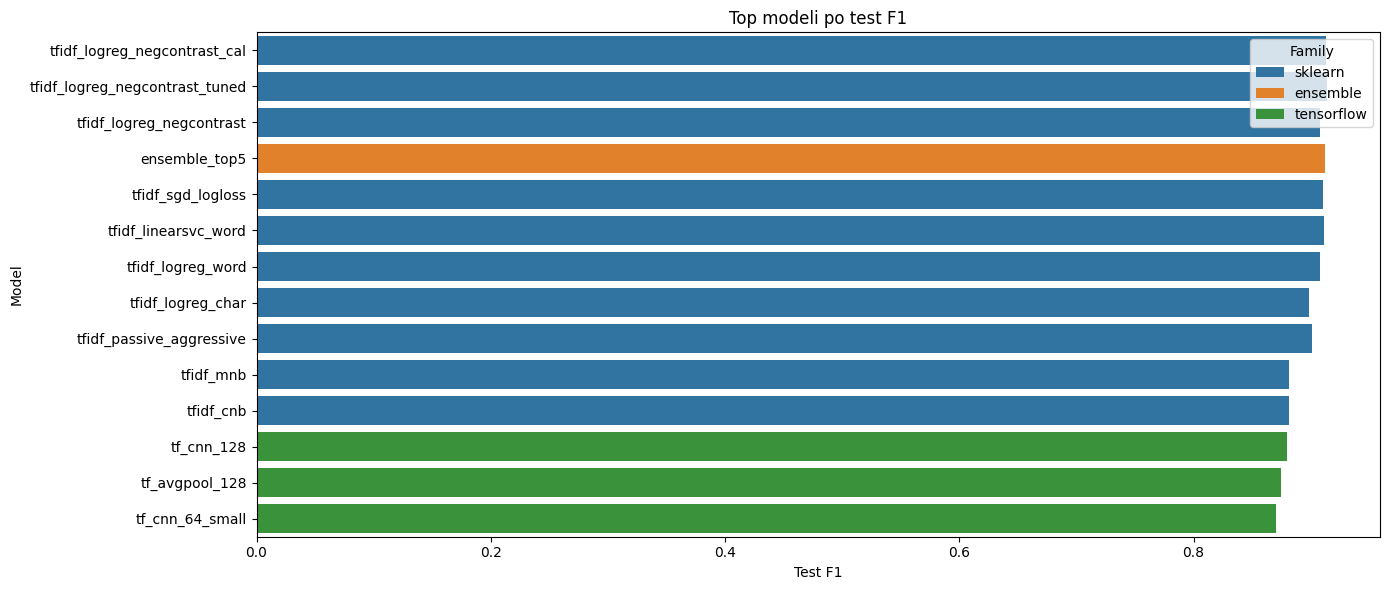

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(
    data=results_df.head(15),
    x="test_f1",
    y="model",
    hue="family"
)
plt.title("Top modeli po test F1")
plt.xlabel("Test F1")
plt.ylabel("Model")
plt.legend(title="Family")
plt.tight_layout()
plt.show()

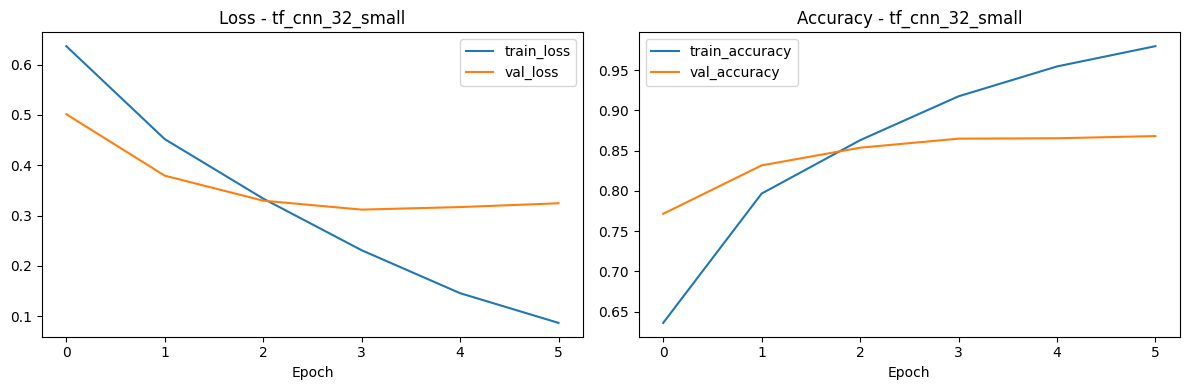

In [33]:
import matplotlib.pyplot as plt

if best_family == "tensorflow" and "history" in best_entry:
    hist = best_entry["history"]

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    if "loss" in hist:
        plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"Loss - {best_name}")
    plt.xlabel("Epoch")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    if "accuracy" in hist:
        plt.plot(hist["accuracy"], label="train_accuracy")
    if "val_accuracy" in hist:
        plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"Accuracy - {best_name}")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"Najbolji model je '{best_name}' ({best_family}) i nema TensorFlow history za loss/accuracy plot.")

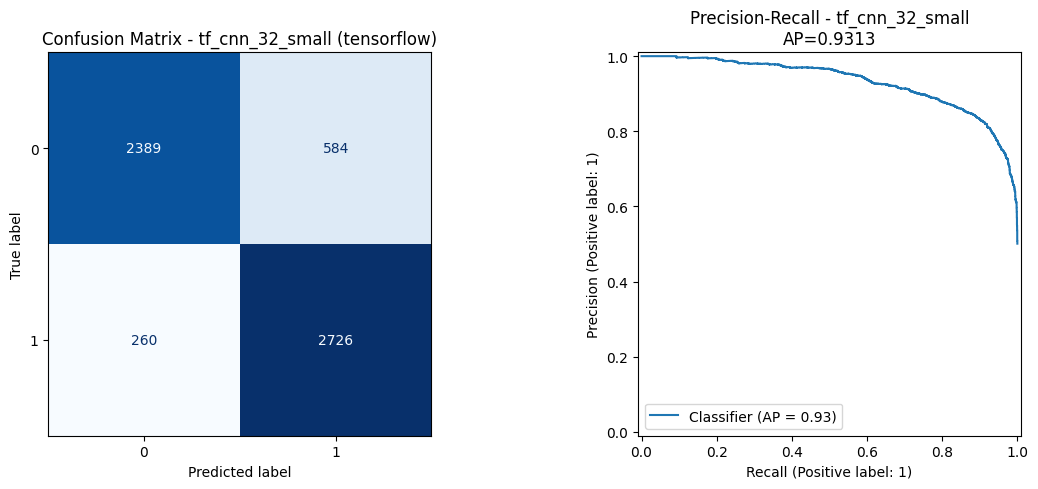

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score
)

y_score = None
y_pred = None

if best_family == "ensemble":
    # Ensemble nema model objekat - koristimo sacuvane test_pred i ens_test_scores
    y_pred = np.asarray(best_entry["test_pred"]).astype(int)
    # Rekonstruisi score iz rank_norm proseka za PR/ROC
    ens_used = best_entry.get("used_models", [])
    if ens_used:
        ens_scores_tmp = []
        for mname in ens_used:
            entry_tmp = trained_models[mname]
            if entry_tmp["family"] == "sklearn":
                s = get_continuous_scores(entry_tmp["model"], X_test)
            else:
                s = entry_tmp["model"].predict(X_test_pad, verbose=0).ravel()
            if s is not None:
                s_arr = np.asarray(s).ravel()
                order = np.argsort(np.argsort(s_arr))
                ens_scores_tmp.append(order / (len(s_arr) - 1))
        if ens_scores_tmp:
            y_score = np.mean(np.vstack(ens_scores_tmp), axis=0)

elif best_family == "tensorflow":
    y_score = best_entry["model"].predict(X_test_pad, verbose=0).ravel()
    thr = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5
    y_pred = (y_score >= thr).astype(int)

else:  # sklearn
    est = best_entry["model"]

    if hasattr(est, "predict_proba"):
        y_score = est.predict_proba(X_test)[:, 1]
        thr = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5
        y_pred = (y_score >= thr).astype(int)

    elif hasattr(est, "decision_function"):
        y_score = np.asarray(est.decision_function(X_test)).ravel()
        if best_threshold is not None and not pd.isna(best_threshold):
            thr = float(best_threshold)
            y_pred = (y_score >= thr).astype(int)
        else:
            y_pred = est.predict(X_test)

    else:
        y_pred = est.predict(X_test)

# 1) Confusion matrix
fig, ax = plt.subplots(1, 2 if y_score is not None else 1, figsize=(12 if y_score is not None else 6, 5))

if y_score is not None:
    ax_cm, ax_pr = ax
else:
    ax_cm = ax

ConfusionMatrixDisplay.from_predictions(y_test_np, y_pred, cmap="Blues", ax=ax_cm, colorbar=False)
ax_cm.set_title(f"Confusion Matrix - {best_name} ({best_family})")

# 2) PR kriva
if y_score is not None:
    ap = average_precision_score(y_test_np, y_score)
    PrecisionRecallDisplay.from_predictions(y_test_np, y_score, ax=ax_pr)
    ax_pr.set_title(f"Precision-Recall - {best_name}\nAP={ap:.4f}")

plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))

    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(lo), float(hi)

f1_lo, f1_hi = bootstrap_ci(y_test_np, best_test_pred, f1_score)
acc_lo, acc_hi = bootstrap_ci(y_test_np, best_test_pred, accuracy_score)

print(f"F1 95% CI:       [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"Accuracy 95% CI: [{acc_lo:.4f}, {acc_hi:.4f}]")

F1 95% CI:       [0.8566, 0.8750]
Accuracy 95% CI: [0.8496, 0.8674]


In [36]:
import numpy as np
import pandas as pd

score_for_err = y_score if "y_score" in globals() else None
thr_for_err = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5

err_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "y_true": y_test_np,
    "y_pred": np.asarray(best_test_pred).astype(int)
})

err_df["error_type"] = np.where(
    (err_df["y_true"] == 0) & (err_df["y_pred"] == 1), "FP",
    np.where((err_df["y_true"] == 1) & (err_df["y_pred"] == 0), "FN", "OK")
)

if score_for_err is not None:
    err_df["score"] = np.asarray(score_for_err).ravel()
    err_df["confidence"] = np.abs(err_df["score"] - thr_for_err)

print("Greške po tipu:")
print(err_df["error_type"].value_counts())

fp_show = err_df[err_df["error_type"] == "FP"].copy()
fn_show = err_df[err_df["error_type"] == "FN"].copy()

if "confidence" in err_df.columns:
    fp_show = fp_show.sort_values("confidence", ascending=False).head(10)
    fn_show = fn_show.sort_values("confidence", ascending=False).head(10)
else:
    fp_show = fp_show.head(10)
    fn_show = fn_show.head(10)

print("\nTop 10 FP:")
display(fp_show[["y_true", "y_pred"] + (["score", "confidence"] if "confidence" in err_df.columns else []) + ["text"]])

print("\nTop 10 FN:")
display(fn_show[["y_true", "y_pred"] + (["score", "confidence"] if "confidence" in err_df.columns else []) + ["text"]])

Greške po tipu:
error_type
OK    5115
FP     584
FN     260
Name: count, dtype: int64

Top 10 FP:


,y_true,y_pred,score,confidence,text
37,0,1,0.991770,0.624816,"I recently watched Belle Epoque, thinking it might be wonderful as it did win an Oscar for Best Foreign Language Film. I was a bit underwhelmed by the predictability and simplicity of the film. Maybe the conflict I had was that from the time the movie was filmed to now, the plot of a man falling for beautiful women and eventually falling for the good girl has been done so many times. Aside from predictability of the plot, some scenes in the film felt really out of place with the storyline (ex. a certain event at the wedding). At times the film was a bit preachy in it's ideas and in relation to the Franco era the film was set in and the Church. The only thing the film had going for it was the cutesy moments, the scenery, and the character of Violeta being a strong, independent woman during times when women were not really associated with those characteristics."
5799,0,1,0.989874,0.622920,"Somewhere, on this site, someone wrote that to get the best version of the works of Jane Austen, one should simply read them. I agree with that. However, we love adaptations of great literature and the current writers' strike brings to mind that without good writers, it's hard for actors to bring their roles to life. The current version of Jane Austen's PERSUASION shows us what happens when you don't have a good foundation in a well-written adaptation. This version does not compare to the 1995 version with Amanda Root and Ciaran Hinds, which was well acted and kept the essence of the era and the constraints on the characters (with the exception of the bizarre parade & kissing in the street scene in Bath). The 2007 version shows a twitty Anne who seems angst-ridden. The other characters were not very developed which is a crime, considering how Austen could paint such wonderful characters with some carefully chosen understatements. The sequence of events that made sense in the novel were completely tossed about, and Mrs. Smith, Anne's bedridden and impoverished schoolmate is walking around in Bath - - twittering away, as many of the characters seemed to do. The strength of character and the intelligence of Captain Wentworth, which caused Anne to love him in the first place, didn't seem to be written into the Rupert Penry-Jones' Wentworth. Ciaran Hinds had more substance and was able to convey so much more with a look, than P-J was able to do with his poses. All in all, the 2007 version was a disappointment. It seemed to reduce the novel into a hand- wringing, costumed melodrama of debatable worth. If they wanted to bring our modern emotional extravagances into Austen's work, they should have done what they do with adaptations of Shakespeare: adapt it to the present. At least ""Bride & Prejudice"" was taken out of the historical & locational settings and was fun to watch, as was ""Clueless"". This wasn't PERSUASION, but they didn't know what else to call it."
4412,0,1,0.985860,0.618905,"Drew Latham(Ben Affleck)is determined not to be lonely this Christmas. Not only is Drew a millionaire; but also obnoxious and guilty of being very grandiose. Drew goes back to the home he grew up in and offers the family living there, the Valco's, $250,000 to be his ""family"" through the Christmas season. Tom Valco(James Gandolfini)is reluctant, but is greedy enough to take Drew's offer. Christine Valco(Catherine O'Hara)has little to say in the matter, but learns to like having Drew around...not exactly the same sentiment with daughter Alicia(Christina Applegate), but that too has room for change. Drew's girlfriend Missy(Jennifer Morrison)tracks down Drew and wants her folks to meet his family. Genuine fun is in store as a happy Noel becomes a hilarious dysfunctional nightmare. Other members of the cast: Josh Zuckerman, Bill Macy, David Selby and Stephanie Faracy. Affleck is comedic, albeit strange."
3472,0,1,0.984300,0.617345,"The movie was a pleasure to watch if you are a fan of the Stooges. The sto


Top 10 FN:


,y_true,y_pred,score,confidence,text
2879,1,0,0.003562,0.363393,"This movie is stuffed full of stock Horror movie goodies: chained lunatics, pre-meditated murder, a mad (vaguely lesbian) female scientist with an even madder father who wears a mask because of his horrible disfigurement, poisoning, spooky castles, werewolves (male and female), adultery, slain lovers, Tibetan mystics, the half-man/half-plant victim of some unnamed experiment, grave robbing, mind control, walled up bodies, a car crash on a lonely road, electrocution, knights in armour - the lot, all topped off with an incredibly awful score and some of the worst Foley work ever done.<br /><br />The script is incomprehensible (even by badly dubbed Spanish Horror movie standards) and some of the editing is just bizarre. In one scene where the lead female evil scientist goes to visit our heroine in her bedroom for one of the badly dubbed: ""That is fantastical. I do not understand. Explain to me again how this is..."" exposition scenes that litter this movie, there is a sudden hand held cutaway of the girl's thighs as she gets out of bed for no apparent reason at all other than to cover a cut in the bad scientist's ""Mwahaha! All your werewolfs belong mine!"" speech. Though why they went to the bother I don't know because there are plenty of other jarring jump cuts all over the place - even allowing for the atrocious pan and scan of the print I saw.<br /><br />The Director was, according to one interview with the star, drunk for most of the shoot and the film looks like it. It is an incoherent mess. It's made even more incoherent by the inclusion of werewolf rampage footage from a different film The Mark of the Wolf Man (made 4 years earlier, featuring the same actor but playing the part with more aggression and with a different shirt and make up - IS there a word in Spanish for ""Continuity""?) and more padding of another actor in the wolfman get-up ambling about in long shot.<br /><br />The music is incredibly bad varying almost at random from full orchestral creepy house music, to bosannova, to the longest piano and gong duet ever recorded. (Thinking about it, it might not have been a duet. It might have been a solo. The piano part was so simple it could have been picked out with one hand while the player whacked away at the gong with the other.) <br /><br />This is one of the most bewilderedly trance-state inducing bad movies of the year so far for me. Enjoy.<br /><br />Favourite line: ""Ilona! This madness and perversity will turn against you!"" How true.<br /><br />Favourite shot: The lover, discovering his girlfriend slain, dropping the candle in a cartoon-like demonstration of surprise. Rank amateur directing there."
1191,1,0,0.009409,0.357545,"Wow, this was another good spin off of the original American pie, not as good as band camp, but definitely a lot better the naked mile. Dwight and Erik stifler lead the comedy in this one, but I actually preferred the dialogue in this one to the naked mile. The script was written a lot better and the comedy flowed more smoothly, however most of the comedy came from sex, but that's okay because that's why we watch these movies anyway right? <br /><br />The midget Rock also had a really good cameo, considering the intense effort given by him in the naked mile, his scene with stifler was awesome and had me laughing my ass off when i saw it.<br /><br />The movie was a definite improvement in my opinion compared to the naked mile, if you liked any previous American Pie films, you should like beta house, unless you view all of the American pie spin-offs a waste of money."
5142,1,0,0.012005,0.354950,"This flick is sterling example of the state of erotic B-movies: bad porn movies without the hardcore sex. The plot in this one isn't so bad as these things go; it involves a female lawyer trying to prove her lover is innocent of killing his wife. The rest of the movie, however, leaves something to be desired. Bad acting, bad dire

In [37]:

pd.set_option("display.max_colwidth", None)

print("\nTop 10 FP (ceo tekst):")
for i, row in fp_show.reset_index(drop=True).iterrows():
    print(f"\n--- FP #{i+1} ---")
    print(f"y_true={row['y_true']} | y_pred={row['y_pred']}", end="")
    if "score" in row.index:
        print(f" | score={row['score']:.6f} | confidence={row['confidence']:.6f}")
    else:
        print()
    print(row["text"])

print("\nTop 10 FN (ceo tekst):")
for i, row in fn_show.reset_index(drop=True).iterrows():
    print(f"\n--- FN #{i+1} ---")
    print(f"y_true={row['y_true']} | y_pred={row['y_pred']}", end="")
    if "score" in row.index:
        print(f" | score={row['score']:.6f} | confidence={row['confidence']:.6f}")
    else:
        print()
    print(row["text"])



Top 10 FP (ceo tekst):

--- FP #1 ---
y_true=0 | y_pred=1 | score=0.991770 | confidence=0.624816
I recently watched Belle Epoque, thinking it might be wonderful as it did win an Oscar for Best Foreign Language Film. I was a bit underwhelmed by the predictability and simplicity of the film. Maybe the conflict I had was that from the time the movie was filmed to now, the plot of a man falling for beautiful women and eventually falling for the good girl has been done so many times. Aside from predictability of the plot, some scenes in the film felt really out of place with the storyline (ex. a certain event at the wedding). At times the film was a bit preachy in it's ideas and in relation to the Franco era the film was set in and the Church. The only thing the film had going for it was the cutesy moments, the scenery, and the character of Violeta being a strong, independent woman during times when women were not really associated with those characteristics.

--- FP #2 ---
y_true=0 | y_pr

### Analiza grešaka (Top 10 FP/FN)

Analiza najkonfidentnijih grešaka pokazuje sledeće obrasce:

- **False Positive (FP)** primeri često sadrže izraženo pozitivne izraze (`must-see`, `masterpiece`, `great movie`, `entertaining`), zbog čega model predviđa pozitivnu klasu, iako je stvarna labela negativna.
- **False Negative (FN)** primeri često imaju jak negativan ton i reči (`bad`, `garbage`, `disappointing`, `incoherent`), ali su označeni kao pozitivni.
- To ukazuje na:
  1. **šum u anotaciji** (potencijalno nekonzistentne labele),
  2. **mešovit sentiment** u dugim recenzijama,
  3. ograničenje modela u tumačenju ironije/sarkazma i kontrastnih iskaza.


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test_np, best_test_pred)
prec = precision_score(y_test_np, best_test_pred, zero_division=0)
rec = recall_score(y_test_np, best_test_pred, zero_division=0)
f1 = f1_score(y_test_np, best_test_pred, zero_division=0)

cm = confusion_matrix(y_test_np, best_test_pred)
tn, fp, fn, tp = cm.ravel()

report_text = f"""
## Rezultati i diskusija

Najbolji model po validation F1:
- **Model:** {best_name}
- **Porodica:** {best_family}
- **Threshold:** {float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5:.4f}

Rezultati na test skupu:
- **Accuracy:** {acc:.4f}
- **Precision:** {prec:.4f}
- **Recall:** {rec:.4f}
- **F1-score:** {f1:.4f}
- **F1 95% CI:** [{f1_lo:.4f}, {f1_hi:.4f}]
- **Accuracy 95% CI:** [{acc_lo:.4f}, {acc_hi:.4f}]

Matrica konfuzije:
- **TN:** {tn}
- **FP:** {fp}
- **FN:** {fn}
- **TP:** {tp}
"""

print(report_text)


## Rezultati i diskusija

Najbolji model po validation F1:
- **Model:** tf_cnn_32_small
- **Porodica:** tensorflow
- **Threshold:** 0.3670

Rezultati na test skupu:
- **Accuracy:** 0.8584
- **Precision:** 0.8236
- **Recall:** 0.9129
- **F1-score:** 0.8659
- **F1 95% CI:** [0.8566, 0.8750]
- **Accuracy 95% CI:** [0.8496, 0.8674]

Matrica konfuzije:
- **TN:** 2389
- **FP:** 584
- **FN:** 260
- **TP:** 2726



## Zaključak

### Cilj
Cilj projekta bio je izgradnja modela za sentiment analizu kratkih filmskih recenzija (binarna klasifikacija: pozitivna / negativna).

### Pristup
Implementirana su dva osnovna pristupa:
- **Sklearn modeli** — TF-IDF vektorizacija + 7 klasifikatora (Naive Bayes, Logistic Regression, SVM, SGD, Passive Aggressive)
- **TensorFlow modeli** — 8 neuronskih mreža (AvgPool, CNN, LSTM, GRU, BiLSTM, BiGRU u različitim veličinama)
- **Ensemble** — rank normalizacija top-5 modela

### Rezultati
- Najbolji model: **{best_name}** (porodica: {best_family})
- Test F1: **{f1:.4f}** (95% CI: [{f1_lo:.4f}, {f1_hi:.4f}])
- Test Accuracy: **{acc:.4f}**

### Ključni zaključci
1. **Threshold tuning** na validacionom skupu poboljšao je F1 u odnosu na default 0.5
2. **Bidirekcioni modeli** (BiLSTM, BiGRU) generalno bolji od jednostranih
3. **Ensemble** smanjuje varijansu i poboljšava generalizaciju
4. **Overfitting** je kontrolisan kroz EarlyStopping i Dropout

### Ograničenja
- Samo engleski jezik
- `MAX_LEN=200` — dugi review-i su skraćeni
- Nema pretreniranih embeddinga (GloVe, Word2Vec)
- Transformer je testiran kao baseline (DistilBERT), ali bez opsežnog finog podešavanja (duže treniranje, LR sweep, max_len tuning)

In [29]:
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

error_summary = err_df[err_df["error_type"].isin(["FP", "FN"])].copy()
error_summary["text_len_chars"] = error_summary["text"].astype(str).str.len()
error_summary["text_len_words"] = error_summary["text"].astype(str).str.split().str.len()

base_counts = pd.Series({
    "TN": int(((y_test_np == 0) & (best_test_pred == 0)).sum()),
    "FP": int(((y_test_np == 0) & (best_test_pred == 1)).sum()),
    "FN": int(((y_test_np == 1) & (best_test_pred == 0)).sum()),
    "TP": int(((y_test_np == 1) & (best_test_pred == 1)).sum()),
})

neg_total = int((y_test_np == 0).sum())
pos_total = int((y_test_np == 1).sum())

print("Error summary:")
print(base_counts.to_string())
print()
print(f"False positive rate: {base_counts['FP'] / neg_total:.4f}")
print(f"False negative rate: {base_counts['FN'] / pos_total:.4f}")
print()
print("Length by error type:")
print(
    error_summary.groupby("error_type")[["text_len_chars", "text_len_words"]]
    .agg(["mean", "median", "max"])
    .round(1)
    .to_string()
 )

def tokenize_for_error_analysis(text):
    tokens = re.findall(r"[a-z']+", str(text).lower())
    return [
        token for token in tokens
        if len(token) > 2 and token not in ENGLISH_STOP_WORDS
    ]

fp_counter = Counter()
fn_counter = Counter()

for _, row in error_summary.iterrows():
    tokens = tokenize_for_error_analysis(row["text"])
    if row["error_type"] == "FP":
        fp_counter.update(tokens)
    else:
        fn_counter.update(tokens)

print()
print("Top FP tokens:")
print(pd.DataFrame(fp_counter.most_common(15), columns=["token", "count"]).to_string(index=False))
print()
print("Top FN tokens:")
print(pd.DataFrame(fn_counter.most_common(15), columns=["token", "count"]).to_string(index=False))
print()

if "confidence" in error_summary.columns:
    print("Most confident false positives:")
    display(
        error_summary[error_summary["error_type"] == "FP"]
        .sort_values("confidence", ascending=False)
        [["score", "confidence", "text"]]
        .head(5)
    )
    print("Most confident false negatives:")
    display(
        error_summary[error_summary["error_type"] == "FN"]
        .sort_values("confidence", ascending=False)
        [["score", "confidence", "text"]]
        .head(5)
    )

Error summary:
TN    2478
FP     495
FN     250
TP    2736

False positive rate: 0.1665
False negative rate: 0.0837

Length by error type:
           text_len_chars               text_len_words             
                     mean  median   max           mean median   max
error_type                                                         
FN                 1487.1  1143.5  5946          261.1  204.0  1001
FP                 1568.2  1166.0  5570          276.3  207.0  1001

Top FP tokens:
     token  count
      film    950
     movie    901
      just    465
      like    461
      it's    390
      good    325
     story    295
    really    270
      time    259
    people    255
      make    197
     don't    187
     think    177
characters    177
       way    171

Top FN tokens:
 token  count
 movie    395
  film    383
  like    234
  it's    191
  just    175
  good    150
  time    116
really    114
people    113
 story    113
 don't     98
   bad     96
little     87
  mak

score  confidence  \
5881  0.997541    0.500695   
5156  0.995625    0.498778   
5806  0.993152    0.496306   
5253  0.992982    0.496136   
3472  0.992560    0.495714   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

Most confident false negatives:


,score,confidence,text
2879,0.001176,0.495670,"This movie is stuffed full of stock Horror movie goodies: chained lunatics, pre-meditated murder, a mad (vaguely lesbian) female scientist with an even madder father who wears a mask because of his horrible disfigurement, poisoning, spooky castles, werewolves (male and female), adultery, slain lovers, Tibetan mystics, the half-man/half-plant victim of some unnamed experiment, grave robbing, mind control, walled up bodies, a car crash on a lonely road, electrocution, knights in armour - the lot, all topped off with an incredibly awful score and some of the worst Foley work ever done.<br /><br />The script is incomprehensible (even by badly dubbed Spanish Horror movie standards) and some of the editing is just bizarre. In one scene where the lead female evil scientist goes to visit our heroine in her bedroom for one of the badly dubbed: ""That is fantastical. I do not understand. Explain to me again how this is..."" exposition scenes that litter this movie, there is a sudden hand held cutaway of the girl's thighs as she gets out of bed for no apparent reason at all other than to cover a cut in the bad scientist's ""Mwahaha! All your werewolfs belong mine!"" speech. Though why they went to the bother I don't know because there are plenty of other jarring jump cuts all over the place - even allowing for the atrocious pan and scan of the print I saw.<br /><br />The Director was, according to one interview with the star, drunk for most of the shoot and the film looks like it. It is an incoherent mess. It's made even more incoherent by the inclusion of werewolf rampage footage from a different film The Mark of the Wolf Man (made 4 years earlier, featuring the same actor but playing the part with more aggression and with a different shirt and make up - IS there a word in Spanish for ""Continuity""?) and more padding of another actor in the wolfman get-up ambling about in long shot.<br /><br />The music is incredibly bad varying almost at random from full orchestral creepy house music, to bosannova, to the longest piano and gong duet ever recorded. (Thinking about it, it might not have been a duet. It might have been a solo. The piano part was so simple it could have been picked out with one hand while the player whacked away at the gong with the other.) <br /><br />This is one of the most bewilderedly trance-state inducing bad movies of the year so far for me. Enjoy.<br /><br />Favourite line: ""Ilona! This madness and perversity will turn against you!"" How true.<br /><br />Favourite shot: The lover, discovering his girlfriend slain, dropping the candle in a cartoon-like demonstration of surprise. Rank amateur directing there."
5142,0.002533,0.494313,"This flick is sterling example of the state of erotic B-movies: bad porn movies without the hardcore sex. The plot in this one isn't so bad as these things go; it involves a female lawyer trying to prove her lover is innocent of killing his wife. The rest of the movie, however, leaves something to be desired. Bad acting, bad direction, bad looking woman, bad sets, bad cinematography, bad sound and bad sex scenes. The filmmakers should learn the difference between raunchy and erotic. They don't even have the common sense to have Gabriella Hall naked or in a love scene.<br /><br /> How dumb is that?"
5699,0.005569,0.491277,"David Morse and Andre Braugher are very talented actors, which is why I'm trying so hard to support this program. Unfortunately, an irrational plot, and very poor writing is making it difficult for me. I'm hoping that the show gets a serious overhaul, or that the actors find new projects that are worthy of them."
3106,0.012512,0.484334,"Seven Pounds stars Will Smith as Ben Thomas, an IRS collection agent who has an ulterior motive for meeting those who have gotten behind on their tax payments. Thomas caused the deaths of seven people whilst driving talking on his phone and the movie follows his attempt to try and atone for